In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode

In [2]:
dev = device.UnitCellDevice(5,2, device.hardware_params(1e-3), debug=True)
code = TestCode(2, 1)
code.add_row_check(0)
code.add_row_check(0)

data_coords = {0: (0,0), 1: (4,0)}
sched = dev.compile_QEC_schedule(
    code,
    data_coords,
    [],# code.check_cx_layers,
    rounds=1,
    use_highways=True,
    refocus_shuttle_noise=False,
)

[2, 3]
2 (4, 0) [(4, 0), (0, 0)]
POP (4, 0, 'READOUT', 0) with cost 4596.0 (0 + 4596.0)
	ADD (4, 0, 'INTERACTION_ZONE', 0) FROM (4, 0, 'READOUT', 0) WITH COST 100
		estimated cost: 4596.0
	ADD (4, 0, 'SHUTTLE_INTERSECTION', 0) FROM (4, 0, 'READOUT', 0) WITH COST 100
		estimated cost: 4696.0
POP (4, 0, 'INTERACTION_ZONE', 0) with cost 4596.0 (100 + 4496.0)
	ADD (4, 0, 'READOUT', 0) FROM (4, 0, 'INTERACTION_ZONE', 0) WITH COST 100
		talready seen, cost 0, new cost 200
		pass
	ADD (4, 0, 'SHUTTLE_INTERSECTION', 0) FROM (4, 0, 'INTERACTION_ZONE', 0) WITH COST 100
		talready seen, cost 100, new cost 200
		pass
	ADD (4, 0, 'INTERACTION_ZONE', 1) FROM (4, 0, 'INTERACTION_ZONE', 0) WITH COST 100
		estimated cost: 4596.0
POP (4, 0, 'INTERACTION_ZONE', 1) with cost 4596.0 (200 + 4396.0)
	ADD (4, 0, 'READOUT', 1) FROM (4, 0, 'INTERACTION_ZONE', 1) WITH COST 100
		estimated cost: 4696.0
	ADD (4, 0, 'SHUTTLE_INTERSECTION', 1) FROM (4, 0, 'INTERACTION_ZONE', 1) WITH COST 100
		estimated cost: 4596.0

In [3]:
for instr,t in zip(sched.instructions, sched.instruction_start_times):
    print(t, instr)

0 Instantiate(duration=500, error=0.001, qubits=[0, 1], cell_coords=[(0, 0), (4, 0)])
500 EmplaceDisplace(duration=100, error=1e-06, qubit=0, coords=(0, 0), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, error=1e-06, qubit=1, coords=(4, 0), start_component=READOUT, end_component=INTERACTION_ZONE)
600 Instantiate(duration=500, error=0.001, qubits=[2, 3], cell_coords=[(4, 0), (0, 0)])
600 EmplaceDisplace(duration=100, error=1e-06, qubit=2, coords=(4, 0), start_component=READOUT, end_component=INTERACTION_ZONE)
700 Gate(duration=100, error=0.001, qubits=[1, 2], name=GateName.CX)
800 EmplaceDisplace(duration=100, error=1e-06, qubit=2, coords=(4, 0), start_component=INTERACTION_ZONE, end_component=SHUTTLE_INTERSECTION)
900 Shuttle(duration=1000, error=1e-05, qubit=2, start_coords=(4, 0), end_coords=(3, 0))
1900 Shuttle(duration=1000, error=1e-05, qubit=2, start_coords=(3, 0), end_coords=(2, 0))
2900 Shuttle(duration=1000, error=1e-05, qubit=2, sta

In [4]:
code.data_coords

[(0, 0), (1, 0)]

MovieWriter imagemagick unavailable; using Pillow instead.


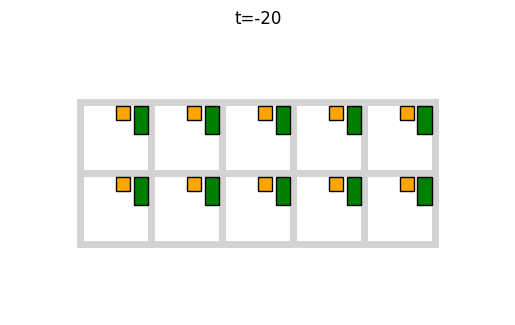

In [5]:
frames = sched.get_frames(20)
# plotter.plot_device_snapshot(dev, code, frames[10])
anim = plotter.animate_device(dev, code, frames, 'anim_test.gif', fps=30)

## Why doesn't the left ancilla qubit just hide in a readout zone while the other one passes??